In [ ]:
"""
===========================================================
Classical CNN Architectures in TensorFlow/Keras
===========================================================
This file demonstrates the use of popular CNN architectures:
    1. LeNet (1998) – First successful CNN for digit recognition.
    2. AlexNet (2012) – Sparked the deep learning revolution in CV.
    3. VGG16 (2014) – Deep but simple (stacked 3x3 conv layers).
    4. ResNet50 (2015) – Introduced skip/residual connections.
    5. DenseNet121 (2017) – Dense connectivity (each layer uses all previous layers).
===========================================================
"""

# 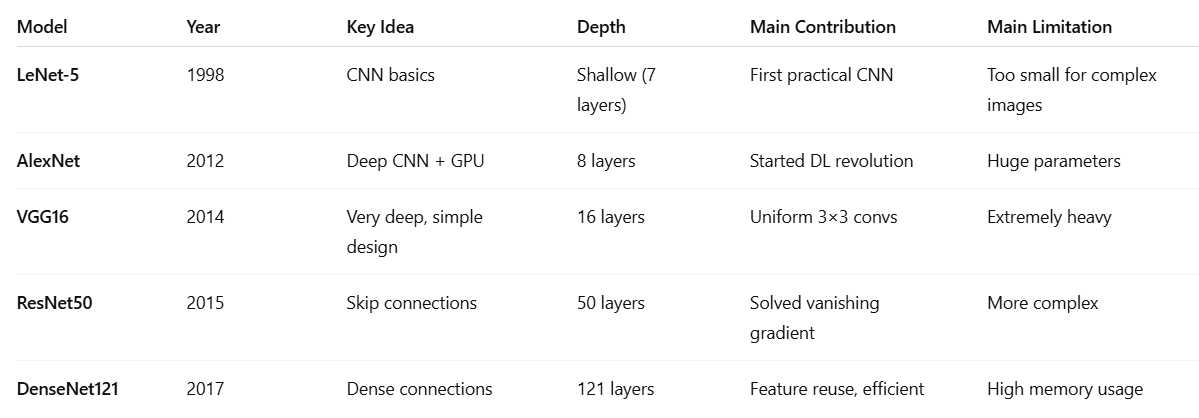

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, datasets

# -------------------------------
# LeNet model definition
# -------------------------------
def build_lenet(input_shape, num_classes):
    """
    LeNet CNN architecture:
    - Conv2D(6,5x5) -> AvgPool
    - Conv2D(16,5x5) -> AvgPool
    - Flatten -> Dense(120) -> Dense(84) -> Dense(num_classes)
    - Activation: 'tanh' for hidden layers, 'softmax' for output
    """
    model = models.Sequential([
        layers.Conv2D(6, kernel_size=5, activation='tanh', input_shape=input_shape, padding='same'),
        layers.AveragePooling2D(pool_size=(2,2)),
        layers.Conv2D(16, kernel_size=5, activation='tanh'),
        layers.AveragePooling2D(pool_size=(2,2)),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# -------------------------------
# Load MNIST dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

# -------------------------------
# Build, compile, and train model
# -------------------------------
lenet = build_lenet((28,28,1), 10)
lenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lenet.fit(x_train, y_train, epochs=2)

# Evaluate test accuracy
test_loss, test_acc = lenet.evaluate(x_test, y_test)
print(f"\nLeNet Test Accuracy: {test_acc:.4f}")

C:\Users\Prikshit_Ishi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9312 - loss: 0.2300
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9715 - loss: 0.0914
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0764   

LeNet Test Accuracy: 0.9765


In [2]:
# -------------------------------
# Sample Predictions
# -------------------------------
sample_images = x_test[:10]
sample_labels = y_test[:10]

pred_probs = lenet.predict(sample_images)
print(pred_probs)
pred_classes = np.argmax(pred_probs, axis=1)

for i in range(10):
    print(f"Image {i+1}: True={sample_labels[i]}, Predicted={pred_classes[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[1.01209380e-05 4.45845353e-06 2.97175255e-04 3.14220175e-04
  1.90858536e-05 9.69605844e-06 1.31643532e-08 9.99220848e-01
  2.59202225e-05 9.83986320e-05]
 [6.71619928e-05 3.13997315e-03 9.94764924e-01 1.28649606e-03
  2.94600377e-05 4.33891473e-05 2.01899631e-04 4.36393179e-08
  4.66210011e-04 4.00288656e-07]
 [1.65685447e-06 9.99652147e-01 6.22601965e-06 2.05286233e-05
  1.38706619e-05 1.31867648e-06 6.38528873e-05 2.08049241e-05
  2.11037826e-04 8.62731940e-06]
 [9.99347866e-01 7.10807129e-08 4.67169230e-05 3.30951889e-06
  2.24979999e-06 2.81535904e-05 2.30830701e-04 9.05432898e-06
  8.72021556e-05 2.44487310e-04]
 [1.17148522e-06 7.98066893e-08 4.45076057e-06 1.25365648e-06
  9.99673724e-01 8.99840870e-06 2.30594906e-05 8.02047871e-05
  9.67337655e-06 1.97319634e-04]
 [1.03884922e-05 9.99252141e-01 1.27198955e-05 3.41120904e-05
  1.50429469e-05 4.33260169e-07 5.53422033e-05 1.26651896e-04
  4.51994798e-04 4.11041765e-05]
 [7.73663146e-07 7.8

C:\Users\Prikshit_Ishi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 237s 149ms/step - accuracy: 0.3802 - loss: 1.6642
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.5189 - loss: 1.3330

AlexNet Test Accuracy: 0.5189
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step

Sample Predictions (True vs Predicted):
Image 1: True=[3], Predicted=3
Image 2: True=[8], Predicted=1
Image 3: True=[8], Predicted=8
Image 4: True=[0], Predicted=8
Image 5: True=[6], Predicted=6
Image 6: True=[6], Predicted=6
Image 7: True=[1], Predicted=1
Image 8: True=[6], Predicted=6
Image 9: True=[3], Predicted=3
Image 10: True=[1], Predicted=1


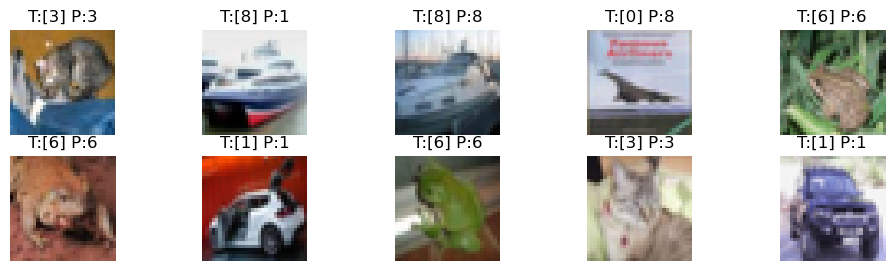

In [2]:
"""
===========================================================
📘 CIFAR-10 Compatible AlexNet in TensorFlow/Keras
===========================================================

This version of AlexNet is adapted for small images (32x32),
so it works with CIFAR-10 without resizing.

Key Changes from Original AlexNet:
- Smaller kernel sizes (3x3 instead of 11x11)
- Strides=1 for first conv layer
- MaxPooling 2x2 instead of 3x3
- Reduced fully connected layer sizes (1024, 512)

===========================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, datasets

# -------------------------------
# Build CIFAR-10 friendly AlexNet
# -------------------------------
def build_alexnet_cifar(input_shape, num_classes):
    """
    AlexNet adapted for CIFAR-10 small images.
    Architecture:
    - Conv(64,3x3,stride=1) -> MaxPool(2x2)
    - Conv(192,3x3) -> MaxPool(2x2)
    - Conv(384,3x3) -> Conv(256,3x3) -> Conv(256,3x3) -> MaxPool(2x2)
    - Flatten -> Dense(1024) -> Dropout -> Dense(512) -> Dropout -> Dense(num_classes)
    - Activation: ReLU for hidden layers, Softmax for output
    """
    model = models.Sequential([
        layers.Conv2D(64, kernel_size=3, strides=1, activation='relu', input_shape=input_shape, padding='same'),
        layers.MaxPooling2D(pool_size=(2,2), strides=2),
        layers.Conv2D(192, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2), strides=2),
        layers.Conv2D(384, kernel_size=3, activation='relu', padding='same'),
        layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
        layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2), strides=2),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# -------------------------------
# Load CIFAR-10 dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# -------------------------------
# Build, compile, and train model
# -------------------------------
alexnet = build_alexnet_cifar((32,32,3), 10)
alexnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
alexnet.fit(x_train, y_train, epochs=1)

# Evaluate test accuracy
test_loss, test_acc = alexnet.evaluate(x_test, y_test)
print(f"\nAlexNet Test Accuracy: {test_acc:.4f}")

# -------------------------------
# Sample Predictions
# -------------------------------
sample_images = x_test[:10]
sample_labels = y_test[:10]

pred_probs = alexnet.predict(sample_images)
pred_classes = np.argmax(pred_probs, axis=1)

print("\nSample Predictions (True vs Predicted):")
for i in range(10):
    print(f"Image {i+1}: True={sample_labels[i]}, Predicted={pred_classes[i]}")

# -------------------------------
# Visualize the images with predictions
# -------------------------------
plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i])
    plt.title(f"T:{sample_labels[i]} P:{pred_classes[i]}")
    plt.axis('off')
plt.show()


In [ ]:
# --------------------------------------------------------
# 3. VGG16 (2014) for CIFAR-10
# --------------------------------------------------------
"""
VGG16: Stacks of 3x3 convolution layers.
Architecture:
- 13 Conv layers + 3 Dense layers
- Activation: ReLU
- Adapted for CIFAR-10 input (32x32x3)
- Training from scratch (weights=None)
"""

from tensorflow.keras.applications import VGG16

# Build VGG16 model for CIFAR-10
# weights=None : learning parameters randomly initialized
vgg = VGG16(weights=None, input_shape=(32,32,3), classes=10)

# Compile the model
vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
vgg.fit(x_train, y_train, epochs=1)

# Evaluate test accuracy
test_loss, test_acc = vgg.evaluate(x_test, y_test)
print(f"\nVGG16 Test Accuracy: {test_acc:.4f}")

# -------------------------------
# Sample Predictions
# -------------------------------
sample_images = x_test[:10]
sample_labels = y_test[:10]  # already 1D

pred_probs = vgg.predict(sample_images)
pred_classes = np.argmax(pred_probs, axis=1)

print("\nSample Predictions (True vs Predicted):")
for i in range(10):
    print(f"Image {i+1}: True={sample_labels[i]}, Predicted={pred_classes[i]}")

# -------------------------------
# Visualize the images with predictions
# -------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i])
    plt.title(f"T:{sample_labels[i]} P:{pred_classes[i]}")
    plt.axis('off')
plt.show()


 207/1563 ━━━━━━━━━━━━━━━━━━━━ 14:53 659ms/step - accuracy: 0.1023 - loss: 2.3039

In [1]:
# --------------------------------------------------------
# 4. ResNet50 (2015) for CIFAR-10
# --------------------------------------------------------
"""
ResNet50: Deep CNN with residual (skip) connections.
- Residual blocks allow training very deep networks.
- Adapted for CIFAR-10 input (32x32x3) with training from scratch.
- Activation: ReLU, final layer: softmax for 10 classes.
"""
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Load CIFAR-10 dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build ResNet50 model for CIFAR-10
# weights=None : learning parameters randomly initialized
resnet = ResNet50(weights=None, input_shape=(32,32,3), classes=10)

# Compile the model
resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
resnet.fit(x_train, y_train, epochs=1)

# Evaluate test accuracy
test_loss, test_acc = resnet.evaluate(x_test, y_test)
print(f"\nResNet50 Test Accuracy: {test_acc:.4f}")

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Sample Predictions (True vs Predicted):
Image 1: True=[3], Predicted=5
Image 2: True=[8], Predicted=9
Image 3: True=[8], Predicted=8
Image 4: True=[0], Predicted=5
Image 5: True=[6], Predicted=4
Image 6: True=[6], Predicted=6
Image 7: True=[1], Predicted=5
Image 8: True=[6], Predicted=4
Image 9: True=[3], Predicted=5
Image 10: True=[1], Predicted=8


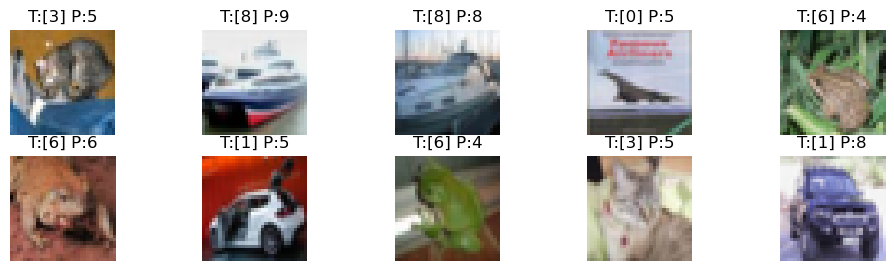

In [11]:
# -------------------------------
# Sample Predictions
# -------------------------------
sample_images = x_test[:10]
sample_labels = y_test[:10]

pred_probs = resnet.predict(sample_images)
pred_classes = np.argmax(pred_probs, axis=1)

print("\nSample Predictions (True vs Predicted):")
for i in range(10):
    print(f"Image {i+1}: True={sample_labels[i]}, Predicted={pred_classes[i]}")

# -------------------------------
# Visualize the images with predictions
# -------------------------------
plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i])
    plt.title(f"T:{sample_labels[i]} P:{pred_classes[i]}")
    plt.axis('off')
plt.show()

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 464s 267ms/step - accuracy: 0.4741 - loss: 1.4825
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.4903 - loss: 1.4795

DenseNet121 Test Accuracy: 0.4903
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Sample Predictions (True vs Predicted):
Image 1: True=[3], Predicted=5
Image 2: True=[8], Predicted=8
Image 3: True=[8], Predicted=0
Image 4: True=[0], Predicted=0
Image 5: True=[6], Predicted=6
Image 6: True=[6], Predicted=1
Image 7: True=[1], Predicted=1
Image 8: True=[6], Predicted=6
Image 9: True=[3], Predicted=3
Image 10: True=[1], Predicted=1


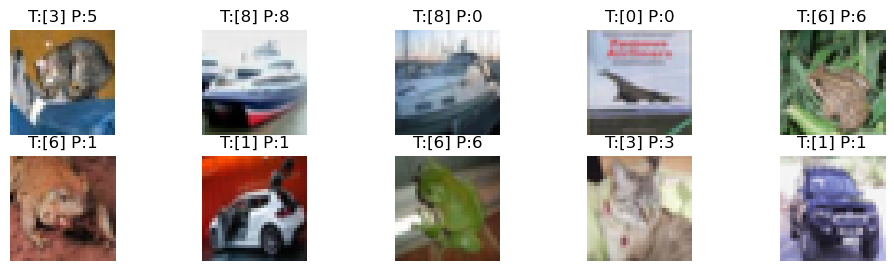


✅ Tutorial Complete: LeNet, AlexNet-CIFAR, VGG16, ResNet50, DenseNet121 demonstrated.


In [13]:
# --------------------------------------------------------
# 5. DenseNet121 (2017) for CIFAR-10
# --------------------------------------------------------
"""
DenseNet121: Each layer receives inputs from all previous layers (dense connectivity).
- Reduces parameters and strengthens gradient flow.
- Adapted for CIFAR-10 input (32x32x3) with training from scratch.
- Activation: ReLU for hidden layers, softmax for output.
"""

from tensorflow.keras.applications import DenseNet121
import matplotlib.pyplot as plt
import numpy as np

# Build DenseNet121 model for CIFAR-10
densenet = DenseNet121(weights=None, input_shape=(32,32,3), classes=10)

# Compile the model
densenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
densenet.fit(x_train, y_train, epochs=1)

# Evaluate test accuracy
test_loss, test_acc = densenet.evaluate(x_test, y_test)
print(f"\nDenseNet121 Test Accuracy: {test_acc:.4f}")

# -------------------------------
# Sample Predictions
# -------------------------------
sample_images = x_test[:10]
sample_labels = y_test[:10]

pred_probs = densenet.predict(sample_images)
pred_classes = np.argmax(pred_probs, axis=1)

print("\nSample Predictions (True vs Predicted):")
for i in range(10):
    print(f"Image {i+1}: True={sample_labels[i]}, Predicted={pred_classes[i]}")

# -------------------------------
# Visualize the images with predictions
# -------------------------------
plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i])
    plt.title(f"T:{sample_labels[i]} P:{pred_classes[i]}")
    plt.axis('off')
plt.show()
